# Week 1 Exercise 1.1

In [2]:
import numpy as np
from activation import ActivationFunction
import matplotlib.pyplot as plt

1. Fill out SignActivation class

In [3]:
class SignActivation(ActivationFunction):
    """ 
        Sign activation: `f(x) = 1 if x > 0, 0 if x <= 0`
    """
    """
        using a simple boolean statement we created the forward to return 0 if false (below 0) and 1 if true (above 0)
    """
    def forward(self, x):
        """
            This is the output function.
        """
        f = int(x>0)
        return f
        
    def gradient(self, x):
        """
            Function derivative.
        """
        return None

In [4]:
actF = SignActivation()
print(actF.forward(1))  # Returns 1
print(actF.forward(0))  # Returns 0
print(actF.forward(-1))  # Returns 0

1
0
0


Here we have a forward function that simply returns either 1 or 0 based on whether the x value is above 0 or equal to or below 0. There is no logic in the gradient function since the question said we did not need to define it. We get the outputs we expect for the values we give the forward function.

2. Implement the initialization of a perceptron in _ _ init _ _

In [6]:
data = np.array( [ [0.5, 0.5, 0], [1.0, 0, 0], [2.0, 3.0, 0], [0, 1.0, 1], [0, 2.0, 1], [1.0, 2.2, 1] ] )
xdata = data[:,:2]
ydata = data[:,2]
print(xdata)
print(ydata)

[[0.5 0.5]
 [1.  0. ]
 [2.  3. ]
 [0.  1. ]
 [0.  2. ]
 [1.  2.2]]
[0. 0. 0. 1. 1. 1.]


In [6]:
class Perceptron:
    """ 
        Perceptron neuron model
        Parameters
        ----------
        n_inputs : int
            Number of inputs
        act_f : Subclass of `ActivationFunction`
            Activation function
    """
    """
        put act_f as the intialized version of the action function class
        put np.random with a variable amount of inputs based on class initialization
    """
    def __init__(self, n_inputs, act_f, w0):
        """
            Perceptron class initialization
            TODO: Write the code to initialize weights and save the given activation function
        """
        if not isinstance(act_f, type) or not issubclass(act_f, ActivationFunction):
            raise TypeError('act_f has to be a subclass of ActivationFunction (not a class instance).')
        # weights
        self.w = np.random.normal(0,0.1,n_inputs) #np.random.normal(mean, standard deviation, size)
        # self.w = np.append([w0], self.w)    # add in bias weight
        self.w0 = w0
        # print(f"{n_inputs} WHYYYYYYY {self.w}")
        # activation function
        self.f = act_f()

        if self.f is not None and not isinstance(self.f, ActivationFunction):
            raise TypeError("self.f should be a class instance.")

In [11]:
x = [0,1]
print(f"xdata: {xdata}")
print(f"ydata: {ydata}")
w0 = 0.5
p = Perceptron(len(xdata[0,:]), SignActivation, w0)
print(p.w)

xdata: [[0.5 0.5]
 [1.  0. ]
 [2.  3. ]
 [0.  1. ]
 [0.  2. ]
 [1.  2.2]]
ydata: [0. 0. 0. 1. 1. 1.]
[-0.00726308  0.145696  ]


For this initial implementation a random mean and standard deviation were chosen to start with which still resulted in semi expected results based on input (aka mean of 0 and sd of 0.1) because these values will be fine tuned later to the example data. The bias was also included as an extra parameter in the class so that it can be adjusted with ease at each call. The activation function class is also initialized through the act_f variable so that it can be easily changed for another activation function if need be.

3. Implement the activation, output and predict functions.

In [33]:
class Perceptron:
    """ 
        Perceptron neuron model
        Parameters
        ----------
        n_inputs : int
            Number of inputs
        act_f : Subclass of `ActivationFunction`
            Activation function
    """
    """
        put act_f as the intialized version of the action function class
        put np.random with a variable amount of inputs based on class initialization
    """
    def __init__(self, n_inputs, act_f, w0):
        """
            Perceptron class initialization
            TODO: Write the code to initialize weights and save the given activation function
        """
        if not isinstance(act_f, type) or not issubclass(act_f, ActivationFunction):
            raise TypeError('act_f has to be a subclass of ActivationFunction (not a class instance).')
        # weights
        self.w = np.random.normal(0,0.1,n_inputs) #np.random.normal(mean, standard deviation, size)
        self.w = np.append([w0], self.w)    # add in bias weight
        self.w0 = w0
        self.f = act_f()

        if self.f is not None and not isinstance(self.f, ActivationFunction):
            raise TypeError("self.f should be a class instance.")

    def activation(self, x):
        """
            It computes the activation `a` given an input `x`
            TODO: Fill in the function to provide the correct output
            NB: Remember the bias
        """
        a = 0
        index = 0
        for val in x:
            a = a + (val*self.w[index])
            index = index + 1
        # a = sum(x * y for x, y in zip(x, self.w))# 1/(1 + np.exp(-x))
        return a

    def output(self, a):
        """
            It computes the neuron output `y`, given the activation `a`
            TODO: Fill in the function to provide the correct output
        """
        y = self.f.forward(a)
        return y

    def predict(self, x):
        """
            It computes the neuron output `y`, given the input `x`
            TODO: Fill in the function to provide the correct output
        """
        x = np.append([1], x)     # adding x0
        a = self.activation(x)
        y = self.output(a)
        return y

In [44]:
x = [0,1]
p = Perceptron(len(xdata[0,:]), SignActivation, 0.5)
print(p.predict(xdata[0,:]))

1


Here the Perceptron class is initialized with a bias of 0.5 (as was done in an example on the slides) and with the SignActivation activation function defined earlier. The results show that the prediction is completely random which is to be expected since there has been no training to fine tune the weights to the input and expected output. The bias is added to the weights array and a one is added to the inputs array so that if the first value of the inputs array is 0 then bias is not taken into account but if it is 1 then it is taken into account (as it is in this case).

4. Write the code to use the previous learning rule for the weight update.

In [4]:
class Perceptron2:
    """ 
        Perceptron neuron model
        Parameters
        ----------
        n_inputs : int
            Number of inputs
        act_f : Subclass of `ActivationFunction`
            Activation function
    """
    """
        put act_f as the intialized version of the action function class
        put np.random with a variable amount of inputs based on class initialization
    """
    def __init__(self, n_inputs, act_f, w0):
        """
            Perceptron class initialization
            TODO: Write the code to initialize weights and save the given activation function
        """
        if not isinstance(act_f, type) or not issubclass(act_f, ActivationFunction):
            raise TypeError('act_f has to be a subclass of ActivationFunction (not a class instance).')
        # weights
        self.w = np.random.normal(0,0.1,n_inputs) #np.random.normal(mean, standard deviation, size)
        # self.w = np.append([w0], self.w)    # add in bias weight
        self.w0 = w0
        # print(f"{n_inputs} WHYYYYYYY {self.w}")
        # activation function
        self.f = act_f()

        if self.f is not None and not isinstance(self.f, ActivationFunction):
            raise TypeError("self.f should be a class instance.")

    def activation(self, x):
        """
            It computes the activation `a` given an input `x`
            TODO: Fill in the function to provide the correct output
            NB: Remember the bias
        """
        w_total = np.append([self.w0], self.w)
        a = 0
        index = 0
        for val in x:
            a = a + (val*w_total[index])
            index = index + 1
        # a = sum(x * y for x, y in zip(x, self.w))# 1/(1 + np.exp(-x))
        return a + self.w0      # add on the bias at the end

    def output(self, a):
        """
            It computes the neuron output `y`, given the activation `a`
            TODO: Fill in the function to provide the correct output
        """
        y = self.f.forward(a)
        return y

    def predict(self, x):
        """
            It computes the neuron output `y`, given the input `x`
            TODO: Fill in the function to provide the correct output
        """
        x = np.append([1], x)     # adding x0
        a = self.activation(x)
        # print("activation results")
        # print(a)
        y = self.output(a)
        return y

    def gradient(self, a):
        """
            It computes the gradient of the activation function, given the activation `a`
        """
        return self.f.gradient(a)

In [59]:
p = Perceptron2(len(xdata[0,:]), SignActivation, w0)
print(p.predict(xdata[0,:]) )

r = 0.1 # learning rate
## calculate the error and update the weights
num_epochs = 70
misclassified_arr = []
for epoch in range(num_epochs):
    print(f"EPOCH: {epoch}")
    misclassified = 0
    for x, label in zip(xdata, ydata):     # xdata = features, ydata = labels
        target = label
        # print(f" TARGET {type(target)}")
        # print(f"x val : {x}")
        output = p.predict(x)
        print(f"OUTPUT: {output}")
        delta_w = (target - output)
        print(f"ERROR: {delta_w}")

        if np.absolute(delta_w) > 0.1:
            print("misclassified")
            misclassified = misclassified + 1
            # x = np.append([1], x)
            # print("AAAAAAAAAAAA")
            # print(r*(delta_w)*x)
            # print(p.w)
            print(f"p_w before: {p.w}")
            p.w = p.w + r*(delta_w)*x
            print(f"p_w after: {p.w}")

    misclassified_arr.append(misclassified)

print(f"RESULTS: {p.w}")
print(misclassified_arr)

1
EPOCH: 0
OUTPUT: 1
ERROR: -1.0
misclassified
p_w before: [-0.12197077  0.00556977]
p_w after: [-0.17197077 -0.04443023]
OUTPUT: 1
ERROR: -1.0
misclassified
p_w before: [-0.17197077 -0.04443023]
p_w after: [-0.27197077 -0.04443023]
OUTPUT: 1
ERROR: -1.0
misclassified
p_w before: [-0.27197077 -0.04443023]
p_w after: [-0.47197077 -0.34443023]
OUTPUT: 1
ERROR: 0.0
OUTPUT: 1
ERROR: 0.0
OUTPUT: 0
ERROR: 1.0
misclassified
p_w before: [-0.47197077 -0.34443023]
p_w after: [-0.37197077 -0.12443023]
EPOCH: 1
OUTPUT: 1
ERROR: -1.0
misclassified
p_w before: [-0.37197077 -0.12443023]
p_w after: [-0.42197077 -0.17443023]
OUTPUT: 1
ERROR: -1.0
misclassified
p_w before: [-0.42197077 -0.17443023]
p_w after: [-0.52197077 -0.17443023]
OUTPUT: 0
ERROR: 0.0
OUTPUT: 1
ERROR: 0.0
OUTPUT: 1
ERROR: 0.0
OUTPUT: 1
ERROR: 0.0
EPOCH: 2
OUTPUT: 1
ERROR: -1.0
misclassified
p_w before: [-0.52197077 -0.17443023]
p_w after: [-0.57197077 -0.22443023]
OUTPUT: 1
ERROR: -1.0
misclassified
p_w before: [-0.57197077 -0.22443

In [65]:
p = Perceptron2(len(xdata[0,:]), SignActivation, w0)
print(p.predict(xdata[0,:]) )

### LOWER LEARNING RATE AND MORE EPOCHS
r = 0.001 # learning rate
## calculate the error and update the weights
num_epochs = 1000
misclassified_arr = []
for epoch in range(num_epochs):
    print(f"EPOCH: {epoch}")
    misclassified = 0
    for x, label in zip(xdata, ydata):     # xdata = features, ydata = labels
        target = label
        # print(f" TARGET {type(target)}")
        # print(f"x val : {x}")
        output = p.predict(x)
        print(f"OUTPUT: {output}")
        delta_w = (target - output)
        print(f"ERROR: {delta_w}")

        if np.absolute(delta_w) > 0.1:
            print("misclassified")
            misclassified = misclassified + 1
            # x = np.append([1], x)
            # print("AAAAAAAAAAAA")
            # print(r*(delta_w)*x)
            # print(p.w)
            print(f"p_w before: {p.w}")
            p.w = p.w + r*(delta_w)*x
            print(f"p_w after: {p.w}")

    misclassified_arr.append(misclassified)

print(f"RESULTS: {p.w}")
print(misclassified_arr)

1
EPOCH: 0
OUTPUT: 1
ERROR: -1.0
misclassified
p_w before: [-0.08271876 -0.02260964]
p_w after: [-0.08321876 -0.02310964]
OUTPUT: 1
ERROR: -1.0
misclassified
p_w before: [-0.08321876 -0.02310964]
p_w after: [-0.08421876 -0.02310964]
OUTPUT: 1
ERROR: -1.0
misclassified
p_w before: [-0.08421876 -0.02310964]
p_w after: [-0.08621876 -0.02610964]
OUTPUT: 1
ERROR: 0.0
OUTPUT: 1
ERROR: 0.0
OUTPUT: 1
ERROR: 0.0
EPOCH: 1
OUTPUT: 1
ERROR: -1.0
misclassified
p_w before: [-0.08621876 -0.02610964]
p_w after: [-0.08671876 -0.02660964]
OUTPUT: 1
ERROR: -1.0
misclassified
p_w before: [-0.08671876 -0.02660964]
p_w after: [-0.08771876 -0.02660964]
OUTPUT: 1
ERROR: -1.0
misclassified
p_w before: [-0.08771876 -0.02660964]
p_w after: [-0.08971876 -0.02960964]
OUTPUT: 1
ERROR: 0.0
OUTPUT: 1
ERROR: 0.0
OUTPUT: 1
ERROR: 0.0
EPOCH: 2
OUTPUT: 1
ERROR: -1.0
misclassified
p_w before: [-0.08971876 -0.02960964]
p_w after: [-0.09021876 -0.03010964]
OUTPUT: 1
ERROR: -1.0
misclassified
p_w before: [-0.09021876 -0.0301

In this version of the Perceptron the bias was not added to the weight but rather added to the a value after summing it all together so that the training calculations aren't thrown off. During the training the absolute value of delta_w needed to be taken so that the if else statement holds up (otherwise negative values which should be considered misclassifications would not be marked as such). This absolute value was taken too soon (as the calculation was made) which resulted in only increasing weight values and therefore no convergence and an increase in misclassifications. But this situation was rectified by taking the absolute value when checking the value in the absolute value. The acceptable value used here is 0.1 but any value above 0 will work since the difference between actual output and excpected output should be 0 to be correct. Convergence was reached at different epochs depending on the learning rate. When r = 0.1 then only 70 epochs were needed but when r = 0.001 then 1000 epochs were needed to reach convergence.

5. These were done before finding 0 misclassifications but they will do for our analysis:  
**lr same for all below (0.001):**  
mean = 0, sd = 0.5, Epochs = 300, final_weights = [-0.50739529  0.00556859]  
mean = 0, sd = 0.1, epochs = 300, final_weights = [-0.436233  -0.0287935]  
mean = 0.5, sd = 0.5, epochs = 300, final_weights = [-0.50134213  0.05605538]  
mean = 0.5, sd = 0.1, epochs = 300, final_weights = [-0.33180395 -0.07261796]  
mean = 0.1, sd = 0.1, epochs = 300, final_weights = [-0.37301496 -0.05593648]  
**lr changes:**  
mean = 0, sd = 0.5, Epochs = 4700, r = 0.001, final_weights = [-1.41751921  0.41736171]  
mean = 0, sd = 0.5, Epochs = 4700, r = 0.1, final_weights = [-1.59847212  0.52009088]  
mean = 0, sd = 0.5, Epochs = 50, r = 0.1, final_weights = [-1.45480675  0.44833558]  

Changing the learning rate didn't change the end results so long as the epochs grew with the reduction of the learning rate number (5000 epochs for lr=0.001 but 50 epochs for lr=0.1). But when it came to changing the other initial values (mean and standard deviation when finding the initial random weights) then the results were a bit different from one another.

When it came to changing the sd the results were fairly similar in regards to the first being around -0.5 and the second being around 0. But when we changed the mean that's when the results changed drastically. The reason behind that could be because the mean is like the starting point for getting random values and the sd is how far we stray from that initial point and therefore the values changed a lot more when we changed the mean.

6. Make a plot of the data points and weight line.

In [18]:
w0 = 0.5
p = Perceptron2(len(xdata[0,:]), SignActivation, w0)
print(p.predict(xdata[0,:]) )

### LOWER LEARNING RATE AND MORE EPOCHS
r = 0.001 # learning rate
## calculate the error and update the weights
num_epochs = 900
misclassified_arr = []
for epoch in range(num_epochs):
    print(f"EPOCH: {epoch}")
    misclassified = 0
    for x, label in zip(xdata, ydata):     # xdata = features, ydata = labels
        target = label
        # print(f" TARGET {type(target)}")
        # print(f"x val : {x}")
        output = p.predict(x)
        print(f"OUTPUT: {output}")
        delta_w = (target - output)
        print(f"ERROR: {delta_w}")

        if np.absolute(delta_w) > 0.1:
            print("misclassified")
            misclassified = misclassified + 1
            # x = np.append([1], x)
            # print("AAAAAAAAAAAA")
            # print(r*(delta_w)*x)
            # print(p.w)
            print(f"p_w before: {p.w}")
            p.w = p.w + r*(delta_w)*x
            print(f"p_w after: {p.w}")

    misclassified_arr.append(misclassified)

print(f"RESULTS: {p.w}")
print(misclassified_arr)

1
EPOCH: 0
OUTPUT: 1
ERROR: -1.0
misclassified
p_w before: [-0.04660057 -0.01915253]
p_w after: [-0.04710057 -0.01965253]
OUTPUT: 1
ERROR: -1.0
misclassified
p_w before: [-0.04710057 -0.01965253]
p_w after: [-0.04810057 -0.01965253]
OUTPUT: 1
ERROR: -1.0
misclassified
p_w before: [-0.04810057 -0.01965253]
p_w after: [-0.05010057 -0.02265253]
OUTPUT: 1
ERROR: 0.0
OUTPUT: 1
ERROR: 0.0
OUTPUT: 1
ERROR: 0.0
EPOCH: 1
OUTPUT: 1
ERROR: -1.0
misclassified
p_w before: [-0.05010057 -0.02265253]
p_w after: [-0.05060057 -0.02315253]
OUTPUT: 1
ERROR: -1.0
misclassified
p_w before: [-0.05060057 -0.02315253]
p_w after: [-0.05160057 -0.02315253]
OUTPUT: 1
ERROR: -1.0
misclassified
p_w before: [-0.05160057 -0.02315253]
p_w after: [-0.05360057 -0.02615253]
OUTPUT: 1
ERROR: 0.0
OUTPUT: 1
ERROR: 0.0
OUTPUT: 1
ERROR: 0.0
EPOCH: 2
OUTPUT: 1
ERROR: -1.0
misclassified
p_w before: [-0.05360057 -0.02615253]
p_w after: [-0.05410057 -0.02665253]
OUTPUT: 1
ERROR: -1.0
misclassified
p_w before: [-0.05410057 -0.0266

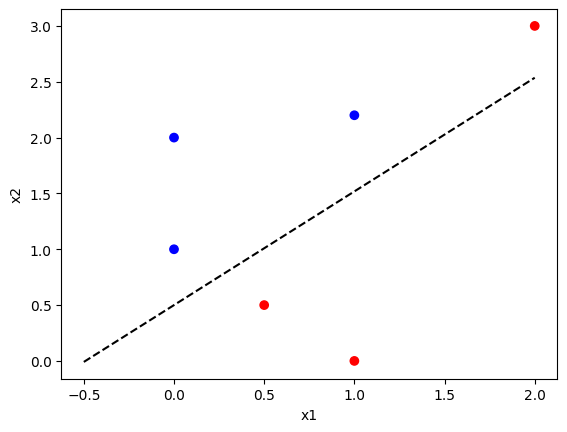

In [19]:
xp = xdata[:,0]
yp = xdata[:,1]

# create line for weights
x = np.linspace(-0.5, 2, 100)
y = np.absolute(p.w[0]+p.w[1])*x+w0     # equation to plot a linear fit

plt.scatter(xp,yp, color=['red','red','red', 'blue', 'blue', 'blue'])
plt.plot(x,y,'k--')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

This graph shows that the line almost fits correctly based on expected output of the datapoints provided. It is unclear why the line doesn't fit 100% but the equation for the weights line was found in an explanatory article related to different Activation Functions and was recommended for the linear activation function. It is the absolute value of the weights added together and multiplied by x which then has the bias added to it.